In [44]:
# imports
import importlib
import download_data
importlib.reload(download_data)
from download_data import get_merged_data
import numpy as np, pandas as pd, holidays
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import pathlib

df = get_merged_data()

In [15]:
# flags & calendar
at_holidays = holidays.Austria()

df["target"]      = df["Load_Actual"].shift(-1)
df["is_weekend"]  = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"]  = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["is_workday"]  = (~df["is_weekend"] & ~df["is_holiday"]).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1

# time-of-day sin / cos
seconds = df["DateTime"].dt.hour*3600 + df["DateTime"].dt.minute*60 + df["DateTime"].dt.second
df["time_sin"] = np.sin(2*np.pi*seconds/86400)
df["time_cos"] = np.cos(2*np.pi*seconds/86400)

# cleanup
df = df.drop(columns=df.filter(like="DayAhead").columns)
df = df[df["DateTime"] >= "2018-10-01"].copy()
df = df.loc[~df.isna().any(axis=1)].copy()

# lags
for l in [1, 2, 3, 4, 96, 192, 672]:
    df[f"load_lag_{l}"] = df["Load_Actual"].shift(l)

# deltas
df["load_diff_1"]    = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"]    = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"]  = df["load_lag_1"] - df["load_lag_96"]
df["load_diff_week"] = df["load_lag_1"] - df["load_lag_672"]

# rolling stats
roll_map = {4:"1h", 24:"6h", 96:"24h", 672:"1w"}
for w, tag in roll_map.items():
    df[f"load_mean_{tag}"] = df["Load_Actual"].rolling(w).mean()
    df[f"load_std_{tag}"]  = df["Load_Actual"].rolling(w).std()
    df[f"load_ramp_{tag}"] = df["Load_Actual"].rolling(w).max() - df["Load_Actual"].rolling(w).min()

df["ema_24h"] = df["Load_Actual"].ewm(span=96).mean()

# annual cycle
angle = 2*np.pi*df["DateTime"].dt.dayofyear/365
df["doy_sin"] = np.sin(angle)
df["doy_cos"] = np.cos(angle)

# time encoding
df["t_int"] = ((df["DateTime"]-df["DateTime"].min())/np.timedelta64(15,"m")).astype(int)

for k in range(1, 4):                  # day (96)
    df[f"day_sin{k}"] = np.sin(2*np.pi*k*df["t_int"]/96)
    df[f"day_cos{k}"] = np.cos(2*np.pi*k*df["t_int"]/96)

for k in range(1, 3):                  # week (672)
    df[f"week_sin{k}"] = np.sin(2*np.pi*k*df["t_int"]/672)
    df[f"week_cos{k}"] = np.cos(2*np.pi*k*df["t_int"]/672)

# final cleanup
df = df.drop(columns=["t_int"]).dropna().reset_index(drop=True)


In [18]:
df.head()

,DateTime,Actual_Solar,Actual_Wind Onshore,Load_Actual,target,is_weekend,is_holiday,is_workday,day_of_week,week_of_year,...,day_sin1,day_cos1,day_sin2,day_cos2,day_sin3,day_cos3,week_sin1,week_cos1,week_sin2,week_cos2
0,2018-10-15 00:00:00,0.0,640.0,5337.2,5316.8,0,0,-1,0,41,...,-1.714506e-15,1.000000,-3.429011e-15,1.000000,1.961911e-15,1.000000,-2.449294e-16,1.000000,-4.898587e-16,1.000000
1,2018-10-15 00:15:00,0.0,592.0,5316.8,5242.8,0,0,-1,0,41,...,6.540313e-02,0.997859,1.305262e-01,0.991445,1.950903e-01,0.980785,9.349842e-03,0.999956,1.869887e-02,0.999825
2,2018-10-15 00:30:00,0.0,584.0,5242.8,5220.4,0,0,-1,0,41,...,1.305262e-01,0.991445,2.588190e-01,0.965926,3.826834e-01,0.923880,1.869887e-02,0.999825,3.739119e-02,0.999301
3,2018-10-15 00:45:00,0.0,588.0,5220.4,5199.6,0,0,-1,0,41,...,1.950903e-01,0.980785,3.826834e-01,0.923880,5.555702e-01,0.831470,2.804626e-02,0.999607,5.607045e-02,0.998427
4,2018-10-15 01:00:00,0.0,596.0,5199.6,5178.8,0,0,-1,0,41,...,2.588190e-01,0.965926,5.000000e-01,0.866025,7.071068e-01,0.707107,3.739119e-02,0.999301,7.473009e-02,0.997204


In [24]:
# feature engineering
AT  = holidays.Austria()
T0  = df["DateTime"].min()

df["target"]       = df["Load_Actual"].shift(-1)
df["is_weekend"]   = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"]   = df["DateTime"].dt.date.map(AT.__contains__).astype(int)
df["is_workday"]   = (~df["is_weekend"] & ~df["is_holiday"]).astype(int)
df["day_of_week"]  = df["DateTime"].dt.weekday
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1

sec = df["DateTime"].dt.hour*3600 + df["DateTime"].dt.minute*60
df["time_sin"] = np.sin(2*np.pi*sec/86400)
df["time_cos"] = np.cos(2*np.pi*sec/86400)

df = (df[df["DateTime"] >= "2018-10-01"]
        .drop(columns=df.filter(like="DayAhead").columns)
        .reset_index(drop=True))

for l in (1, 2, 3, 4, 96, 192, 672):
    df[f"load_lag_{l}"] = df["Load_Actual"].shift(l)

df["load_diff_1"]    = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"]    = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"]  = df["load_lag_1"] - df["load_lag_96"]
df["load_diff_week"] = df["load_lag_1"] - df["load_lag_672"]

for w, tg in ((4, "1h"), (24, "6h"), (96, "24h"), (672, "1w")):
    r = df["Load_Actual"].rolling(w)
    df[f"load_mean_{tg}"]  = r.mean()
    df[f"load_std_{tg}"]   = r.std()
    df[f"load_ramp_{tg}"]  = r.max() - r.min()

df["ema_24h"] = df["Load_Actual"].ewm(span=96).mean()

ang = 2*np.pi*df["DateTime"].dt.dayofyear/365
df["doy_sin"], df["doy_cos"] = np.sin(ang), np.cos(ang)

t_int = ((df["DateTime"] - T0) / np.timedelta64(15, "m")).astype(int)
for k in (1, 2, 3):
    df[f"day_sin{k}"]  = np.sin(2*np.pi*k*t_int/96)
    df[f"day_cos{k}"]  = np.cos(2*np.pi*k*t_int/96)
for k in (1, 2):
    df[f"week_sin{k}"] = np.sin(2*np.pi*k*t_int/672)
    df[f"week_cos{k}"] = np.cos(2*np.pi*k*t_int/672)

df = df.dropna().reset_index(drop=True)

# feature list

drop_cols = {"Load_Actual", "target", "Actual_Solar", "Actual_Wind Onshore"}
num_bool  = df.select_dtypes(include=["number", "bool"]).columns
FEATS     = sorted([c for c in num_bool if c not in drop_cols])

# split train/test and setup XGBoost

split        = int(len(df) * 0.8)
train, test  = df.iloc[:split], df.iloc[split:]


X_train = train[FEATS].to_numpy(dtype=np.float32)
y_train = train["target"].to_numpy(dtype=np.float32)

xgb_model = xgb.XGBRegressor(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
).fit(X_train, y_train)

# recursive 96-step forcast function

ALPHA = 2 / (96 + 1)

def add_fourier(idx15, row):
    for k in (1, 2, 3):
        row[f"day_sin{k}"], row[f"day_cos{k}"] = (
            np.sin(2*np.pi*k*idx15/96),  np.cos(2*np.pi*k*idx15/96)
        )
    for k in (1, 2):
        row[f"week_sin{k}"], row[f"week_cos{k}"] = (
            np.sin(2*np.pi*k*idx15/672), np.cos(2*np.pi*k*idx15/672)
        )

def rec_forecast(mdl, base_row, H=96):
    """Walk the model forward H steps (24 h) with real-time feature updates."""
    hist = deque(df["Load_Actual"].iloc[max(0, base_row.name-672+1):base_row.name+1],
                 maxlen=672)
    cur  = base_row.copy()
    ema  = cur["ema_24h"]
    preds = []

    for _ in range(H):
        # advance 15 minutes
        dt = cur["DateTime"] + pd.Timedelta(minutes=15)
        cur["DateTime"] = dt

        # calendar flags
        dow  = dt.weekday()
        cur["day_of_week"]  = dow
        cur["week_of_year"] = dt.isocalendar().week - 1
        cur["is_weekend"]   = int(dow >= 5)
        cur["is_holiday"]   = int(AT.__contains__(dt.date()))
        cur["is_workday"]   = int(not cur["is_weekend"] and not cur["is_holiday"])

        # intraday seasonality
        sec = dt.hour*3600 + dt.minute*60
        cur["time_sin"], cur["time_cos"] = (
            np.sin(2*np.pi*sec/86400), np.cos(2*np.pi*sec/86400)
        )

        # annual seasonality
        ang = 2*np.pi*dt.timetuple().tm_yday/365
        cur["doy_sin"], cur["doy_cos"] = np.sin(ang), np.cos(ang)

        # Fourier time indices
        add_fourier(int((dt - T0) / pd.Timedelta(minutes=15)), cur)

        # lagged loads
        for lag in (1, 2, 3, 4, 96, 192, 672):
            cur[f"load_lag_{lag}"] = hist[-lag] if len(hist) >= lag else hist[0]

        # deltas
        cur["load_diff_1"]    = cur["load_lag_1"] - cur["load_lag_2"]
        cur["load_diff_4"]    = cur["load_lag_1"] - cur["load_lag_4"]
        cur["load_diff_24h"]  = cur["load_lag_1"] - cur["load_lag_96"]
        cur["load_diff_week"] = cur["load_lag_1"] - cur["load_lag_672"]

        # rolling statistics
        for w, t in ((4, "1h"), (24, "6h"), (96, "24h"), (672, "1w")):
            seg = list(hist)[-w:] if len(hist) >= w else list(hist)
            cur[f"load_mean_{t}"], cur[f"load_std_{t}"], cur[f"load_ramp_{t}"] = (
                np.mean(seg), np.std(seg, ddof=0), max(seg) - min(seg)
            )

        # exponential moving average
        ema = ALPHA * hist[-1] + (1 - ALPHA) * ema
        cur["ema_24h"] = ema

        # same feature matrix as used during training
        feat = cur.reindex(FEATS).astype(float).fillna(0)
        X = feat.to_numpy(dtype=np.float32).reshape(1, -1)
        y_hat = mdl.predict(X)[0]

        preds.append(y_hat)
        hist.append(y_hat)
        cur["Load_Actual"] = y_hat

    return np.array(preds)


# evaluation
H, STRIDE = 96, 4                   # 4 × 15 min = 1 h
idx_sub   = test.index[:-H:STRIDE]

rmse = np.zeros(H); mae = np.zeros(H); mape = np.zeros(H)

for idx in tqdm(idx_sub, desc="Eval 96-Step"):
    base   = df.loc[idx]
    y_true = df["Load_Actual"].iloc[idx+1:idx+H+1].values
    y_pred = rec_forecast(xgb_model, base, H)
    d      = y_true - y_pred
    rmse  += d**2
    mae   += np.abs(d)
    mape  += np.abs(d / y_true)

rmse, mae, mape = (
    np.sqrt(rmse / len(idx_sub)),
    mae / len(idx_sub),
    100 * mape / len(idx_sub ),
)
print(f"H+01  RMSE={rmse[0]:.2f}  MAE={mae[0]:.2f}  MAPE={mape[0]:.2f}%")
print(f"H+96  RMSE={rmse[-1]:.2f} MAE={mae[-1]:.2f} MAPE={mape[-1]:.2f}%")


Eval 96-Step: 100%|██████████| 11367/11367 [52:57<00:00,  3.58it/s] 

H+01  RMSE=83.83  MAE=66.27  MAPE=1.01%
H+96  RMSE=1564.90 MAE=1167.87 MAPE=18.19%


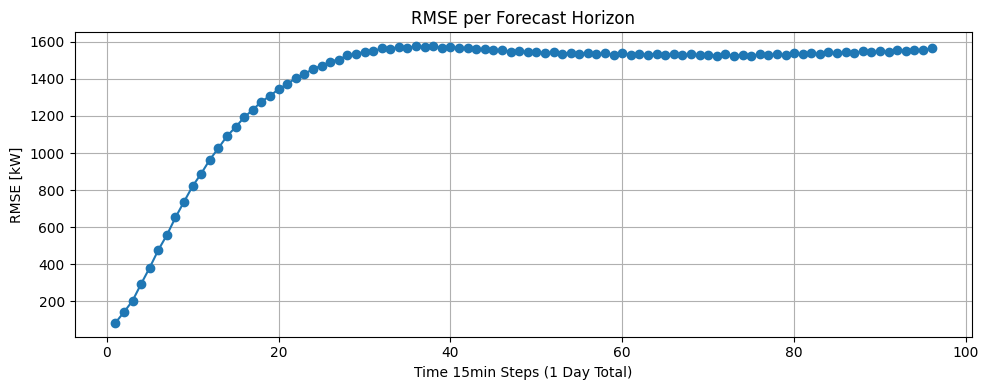

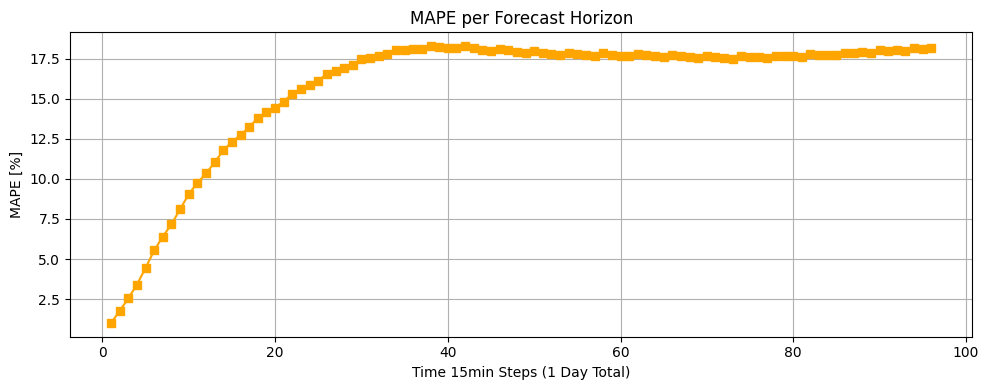

In [25]:
# RMSE per forecast horizon
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(rmse) + 1), rmse, label="RMSE [kW]", marker="o")
plt.ylabel("RMSE [kW]")
plt.xlabel("Time 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("RMSE per Forecast Horizon")
plt.tight_layout()
plt.show()

# MAPE per forecast horizon
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(mape) + 1), mape, label="MAPE [%]", marker="s", color="orange")
plt.ylabel("MAPE [%]")
plt.xlabel("Time 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("MAPE per Forecast Horizon")
plt.tight_layout()
plt.show()

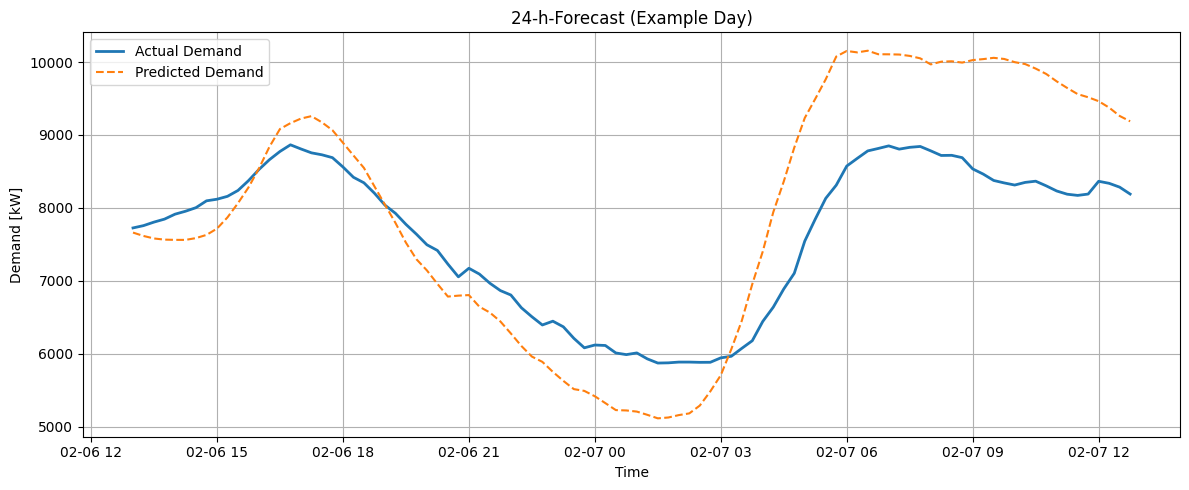

In [26]:
# plot predicted demand vs actual demand
example_i   = 2
base_idx    = idx_sub[example_i]
base_row    = df.loc[base_idx]

y_true_day  = df["Load_Actual"].iloc[base_idx+1 : base_idx+97].values
y_pred_day  = rec_forecast(xgb_model, base_row, H=96)

time_axis = pd.date_range(
    start = base_row["DateTime"] + pd.Timedelta(minutes=15),
    periods = 96, freq = "15min"
)

plt.figure(figsize=(12,5))
plt.plot(time_axis, y_true_day, label="Actual Demand", linewidth=2)
plt.plot(time_axis, y_pred_day, label="Predicted Demand", linestyle="--")
plt.legend(); plt.grid(True)
plt.xlabel("Time"); plt.ylabel("Demand [kW]")
plt.title("24-h-Forecast (Example Day)")
plt.tight_layout(); plt.show()


<Figure size 1000x800 with 0 Axes>

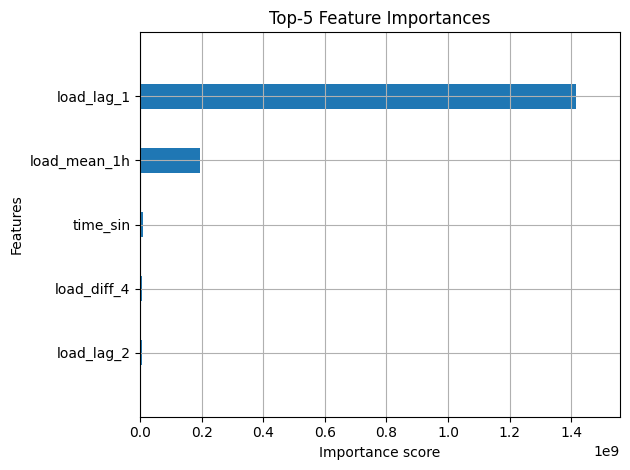

In [32]:
# plot feature importance
booster = xgb_model.get_booster()

booster.feature_names = FEATS

plt.figure(figsize=(10, 8))
xgb.plot_importance(
    booster,
    max_num_features=5,
    height=0.4,
    importance_type="gain",
    show_values=False
)
plt.title("Top-5 Feature Importances")
plt.tight_layout()
plt.show()


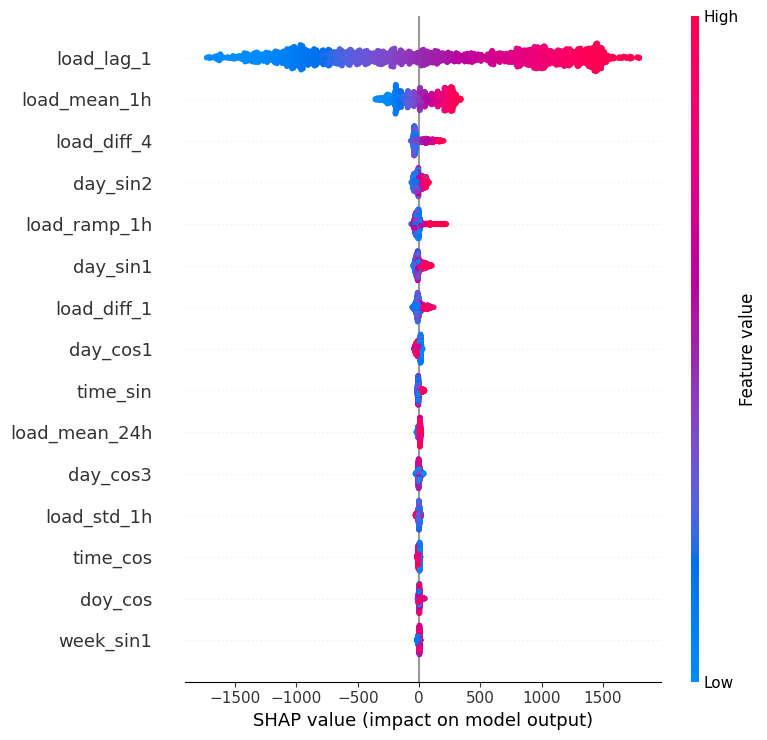

In [30]:
# feature importance explainer
explainer = shap.TreeExplainer(xgb_model)
X_sample_np = test[FEATS].iloc[:2000].to_numpy(dtype=float)
shap_vals = explainer.shap_values(X_sample_np)

shap.summary_plot(
    shap_vals,
    features=X_sample_np,
    feature_names=FEATS,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.show()



In [46]:
RMSE_total = np.sqrt(np.mean(rmse ** 2))
MAPE_total = np.mean(mape)
print(f"RMSE : {RMSE_total:,.2f} kW")
print(f"MAPE : {MAPE_total:,.2f} %")

# -------------------------------------------------------------
# Werte als JSON speichern, damit andere Notebooks sie laden können
# -------------------------------------------------------------
metrics = {
    "RMSE_total": float(RMSE_total),
    "MAPE_total": float(MAPE_total)
}

out_path = pathlib.Path("forecast_metrics.json")   # Pfad anpassen, falls nötig
with out_path.open("w") as f:
    json.dump(metrics, f, indent=2)

RMSE : 1,425.36 kW
MAPE : 15.77 %
